In [1]:
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import numpy as np
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
!cp '/content/gdrive/My Drive/Medios continuos/ezweb_17588.zip' 'enana'

In [3]:
!unzip enana

Archive:  enana
  inflating: structure_00000.txt     
  inflating: structure_00001.txt     
  inflating: structure_00002.txt     
  inflating: structure_00003.txt     
  inflating: structure_00004.txt     
  inflating: structure_00005.txt     
  inflating: structure_00006.txt     
  inflating: structure_00007.txt     
  inflating: structure_00008.txt     
  inflating: structure_00009.txt     
  inflating: structure_00010.txt     
  inflating: structure_00011.txt     
  inflating: structure_00012.txt     
  inflating: structure_00013.txt     
  inflating: structure_00014.txt     
  inflating: structure_00015.txt     
  inflating: structure_00016.txt     
  inflating: structure_00017.txt     
  inflating: structure_00018.txt     
  inflating: structure_00019.txt     
  inflating: structure_00020.txt     
  inflating: structure_00021.txt     
  inflating: structure_00022.txt     
  inflating: structure_00023.txt     
  inflating: structure_00024.txt     
  inflating: structure_00025.txt  

Vamos a estudiar que tan bien funcionan los modelos politrópicos para describir estrellas completamente convectivas.

#1) 
Conseguir en la página de EZWEB (http://www.astro.wisc.edu/~townsend/static.php?ref=ez-web) los datos del interior de una estrella con 0.1 masas solares (enana roja) con 1.000 millones de años.  Grafique el índice adiabático efectivo como función del radio.  Escoja un valor de índice politrópico y calcule usando la solución a la ecuación de Lane-Emden, el radio y masa de la estrella (que están en el archivo "summary.txt"): la temperatura y densidad central de la estella y hacer gráficos de densidad, temperatura y presión usando el modelo politrópico y compararlo con el modelo realista como lo hicimos en clase.

Como primero tenemos la ecuación de Lane-Emden

$$
\frac{1}{\xi^{2}} \frac{d}{d \xi}\left(\xi^{2} \frac{d\theta}{d \xi}\right)+\theta^{\frac{1}{\gamma-1}}=0
$$

Que se puede escribir como:
$$
\frac{d^2\theta}{d \xi^2}=-\frac{2}{\xi}\frac{d\theta}{d \xi}-\theta^{\frac{1}{\gamma-1}}
$$

Donde $\theta=\frac{T(r)}{T_c}$, $\xi=\frac{r}{\lambda}$, $\lambda^2=\frac{c_p T_c}{4\pi G \rho_c}$, $c_p$ es la capacidad calorifica a presión constante, $G$ es la constante gravitacional y $T_c$ y $\rho_c$ son la temperatura y densidad en el centro de la estrella.

En clase encontramos la ecuación para el $\gamma_{eff}$ la cual esta descrita por:

$$\gamma_{eff} = \frac{1}{1-\frac{d \log T}{d \log P}}$$

Las ecuaciones de estado politrópicas son:

$$T^{\gamma_{eff}}P^{1-\gamma_{eff}}= cte$$ 

 $$T\rho^{1-\gamma_{eff}}= cte$$

Las cuales se pueden escribir como:

$$T^{\gamma_{eff}}P^{1-\gamma_{eff}}=T_c^{\gamma_{eff}}P_c^{1-\gamma_{eff}}~~~(1)$$ 

 $$T\rho^{1-\gamma_{eff}}=T_c\rho_c^{1-\gamma_{eff}}~~~(2)$$

Partiendo de (1) y (2) hallaremos las variables de presión, densidad y temperatura.

**Presión:**
Despejando P de (1):

$$P^{1-\gamma_{eff}}=\left( \frac{T_c}{T} \right)^{\gamma_{eff}} P_c^{1-\gamma_{eff}}$$

$$P^{1-\gamma_{eff}}=\theta^{-\gamma_{eff}}P_c^{1-\gamma_{eff}}$$

 $$P=P_c \theta^{\frac{\gamma_{eff}}{\gamma_{eff}-1}}~~~~~(3)$$

**Densidad:**
Despejando $\rho$ de (2):

 $$\rho^{1-\gamma_{eff}}=\frac{T_c}{T}\rho_c^{1-\gamma_{eff}}$$

  $$\rho^{1-\gamma_{eff}}=\theta^{-1}\rho_c^{1-\gamma_{eff}}$$

  $$\rho=\rho_c \theta^{\frac{1}{ \gamma_{eff-1}}}~~~~(4)$$

**Temperatura**
La Temperatura la podemos encontrar directamente de la definición de $\theta$, esta se encuentra con la solución de la ecuación diferencial de Lane-Emden

$$T=T_c \theta~~~~~(5)$$

**Condiciones iniciales:**
Las condiciones iniciales de la EDO las encontramos en clase

$$\theta(0)= 1 ~~~~~~~~~~~ \dot\theta(0)=0$$

**¿Qué pasa si no conozco $T_c$ y $\rho_c$?**

En clase encontramos las siguientes ecuaciones que describen a $T_c$ y $\rho_c$ en términos de $T_0$ y $\rho_0$

$$T_c=\frac{T_0}{-\theta'(\xi_0)\xi_0}$$

$$\rho_c=\rho_0\frac{\xi_0^2}{3}\frac{T_c}{T_0}$$
$$$$

In [4]:
datos1=np.loadtxt("summary.txt")
datos1[:,1]

array([0.00000000e+00, 5.00000000e+04, 1.00000000e+05, 1.60000000e+05,
       2.32000000e+05, 3.18400000e+05, 4.22080000e+05, 5.46496000e+05,
       6.95795200e+05, 8.74954240e+05, 1.08994509e+06, 1.34793411e+06,
       1.65752093e+06, 2.02902511e+06, 2.47483013e+06, 3.00979616e+06,
       3.65175539e+06, 4.42210647e+06, 5.34652777e+06, 6.45583332e+06,
       7.78699998e+06, 9.38439998e+06, 1.13012800e+07, 1.36015360e+07,
       1.63618432e+07, 1.96742118e+07, 2.36490542e+07, 2.84188650e+07,
       3.41426380e+07, 4.10111656e+07, 4.92533987e+07, 5.91440784e+07,
       7.10128941e+07, 8.52554730e+07, 1.02346568e+08, 1.22855881e+08,
       1.47467057e+08, 1.77000469e+08, 2.12440562e+08, 2.54968675e+08,
       3.06002410e+08, 3.67242892e+08, 4.40731470e+08, 5.28917764e+08,
       6.34741317e+08, 7.61729581e+08, 9.14115497e+08, 1.00000000e+09])

In [5]:
datos=np.loadtxt("structure_00047.txt")
Mrs=datos[:,0]
rs=datos[:,1]
ps=datos[:,3]
rhos=datos[:,4]
Ts=datos[:,5]
cps=datos[:,8]

In [6]:
logTs=np.log(Ts)
logps=np.log(ps)
gamma_effs=1/(1-((logTs[1:]-logTs[:-1])/(logps[1:]-logps[:-1])))
gamma_effs

array([1.15307103, 1.15954351, 1.15140388, 1.14529205, 1.14135073,
       1.13927347, 1.13872445, 1.13944849, 1.14127524, 1.14409548,
       1.14784418, 1.15249228, 1.15804028, 1.16451251, 1.17195   ,
       1.18039949, 1.1898967 , 1.20044506, 1.21199761, 1.22445279,
       1.23767177, 1.25151365, 1.2658692 , 1.28066836, 1.29584306,
       1.31123973, 1.32648686, 1.34084432, 1.353132  , 1.36196921,
       1.36647013, 1.36688709, 1.36440503, 1.36058093, 1.3574576 ,
       1.35782849, 1.36453193, 1.37902124, 1.40052528, 1.4264392 ,
       1.45326432, 1.47724109, 1.49481484, 1.50539881, 1.52688176,
       1.60915176, 1.70892458, 1.69757696, 1.63854759, 1.63096738,
       1.65422896, 1.66142375, 1.66060356, 1.65938714, 1.65854937,
       1.65785518, 1.65721516, 1.65664828, 1.65618295, 1.65582781,
       1.65557512, 1.65541004, 1.65531587, 1.65527725, 1.65528131,
       1.65531755, 1.65537756, 1.65545487, 1.65554429, 1.65564211,
       1.65574494, 1.65585074, 1.65595761, 1.65606427, 1.65616

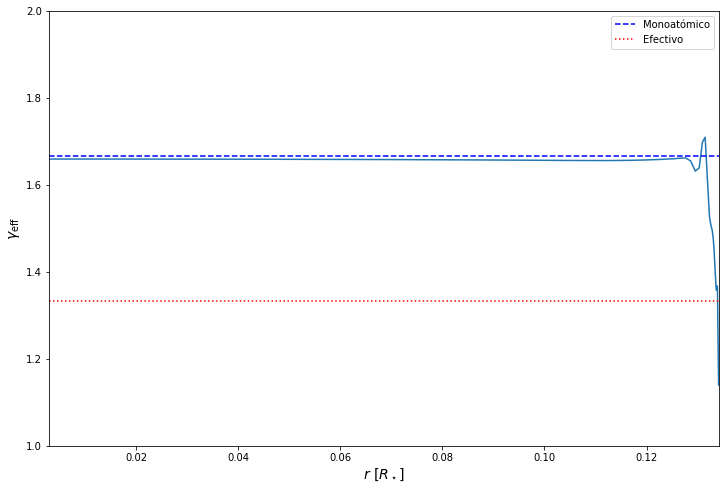

In [7]:
#graficacion del gama efectivo
fig,ax=plt.subplots(figsize=(12,8))
ax.plot(rs[:-1],gamma_effs)
ax.set_ylim(1,2)
ax.axhline(5/3,label="Monoatómico",color='b',ls="--")
ax.axhline(4/3,label="Efectivo",color='r',ls=":")
ax.legend()
ax.set_ylabel(r"$\gamma_{\rm eff}$",fontsize=14)
ax.set_xlabel(r"$r$ [$R_\star$]",fontsize=14)
ax.margins(0)

In [8]:
#Ecuacion de lambert
def lane_emden(Y,x,gamma=5/3):
  teta,tetap=Y

  dtetadr=tetap
  dtetapdr=-2/x*tetap-teta**(1/(gamma-1))

  return np.array([dtetadr,dtetapdr])

In [9]:
#comparacion con el modelo realista
#Asumimiendo
gamma_eff=5/3
xs=np.linspace(1e-2,10,1000)
Yo=[1,0]
solucion=odeint(lane_emden,Yo,xs,args=(gamma_eff,))
teta=solucion[:,0]
tetap=solucion[:,1]
xo=xs[np.invert(np.isnan(teta))][-1]
tetapo=tetap[np.invert(np.isnan(teta))][-1]
print(xo,tetapo)




3.5999999999999996 -0.20940073487969071


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:6: RuntimeWarning: invalid value encountered in double_scalars
  


In [10]:
G=6.67e-11
#Propiedades de la estrella
Rsun=6.96349e8 #m
Msun=1.98e30 #kg
Men=Msun*Mrs[0]
Ren=Rsun*rs[0]
rho0=Men/(4/3*np.pi*Ren**3)
go=G*Men/Ren**2
#Masa molar
Mmol=0.0005 #kg/mol, Mmol para una estrella completamente convectiva
R=8.31446261815324 #J/kg/mol
#Calor específico
cp=gamma_eff/(gamma_eff-1)*R/Mmol
#Condiciones centrales
To=go*Ren/cp
Tc=To/(-tetapo*xo)
rhoc=rho0*xo**2*Tc/(3*To)
Pc=ps[-1]
print(f"Temperatura central {Tc}")
print(f"Densidad central {rhoc}")
print(f"Presión central {Pc}")
#Lambda
lamb=np.sqrt(cp*Tc/(4*np.pi*G*rhoc))
print(f"Lambda = {lamb/1e3} km")
#Finalmente las condiciones son
rs_en=xs*lamb
Ts_en=teta*Tc

rhos_en=rhoc*teta**(1/(gamma_eff-1))

Ps_en=Pc*teta**(gamma_eff/(gamma_eff-1))

Temperatura central 4510778.109927506
Densidad central 332219.6535508238
Presión central 2.49874539e+16
Lambda = 25950.59484771055 km


## Perfil de Temperatura

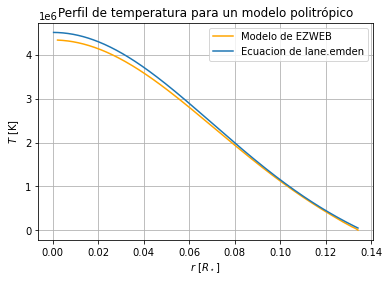

In [11]:
plt.plot(rs,Ts,color="orange",label="Modelo de EZWEB")
plt.plot(rs_en/Rsun,Ts_en,label="Ecuacion de lane.emden")
plt.ylabel(r"$T$ [K]")
plt.xlabel(r"$r$ [$R_\star$]")
plt.title("Perfil de temperatura para un modelo politrópico")
plt.legend()
plt.grid()

## Perfil de densidad

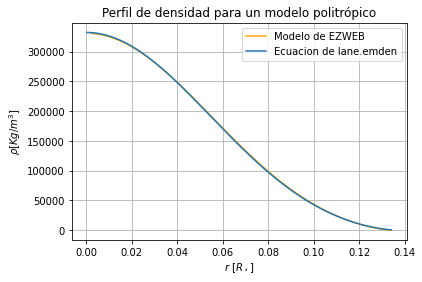

In [12]:
plt.plot(rs,rhos,color="orange",label="Modelo de EZWEB")
plt.plot(rs_en/Rsun,rhos_en,label="Ecuacion de lane.emden")
plt.ylabel(r"$\rho [Kg/m^3]$")
plt.xlabel(r"$r$ [$R_\star$]")
plt.title("Perfil de densidad para un modelo politrópico")
plt.legend()
plt.grid()

## Perfil de Presión

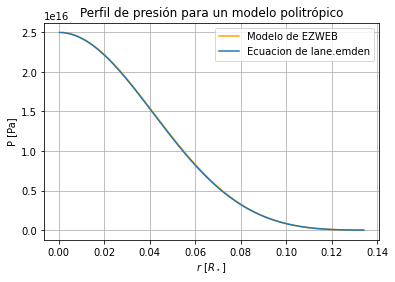

In [13]:
plt.plot(rs,ps,color="orange",label="Modelo de EZWEB")
plt.plot(rs_en/Rsun,Ps_en,label="Ecuacion de lane.emden")
plt.ylabel('P [Pa]')
plt.xlabel(r"$r$ [$R_\star$]")
plt.title("Perfil de presión para un modelo politrópico")
plt.legend()
plt.grid()

Para este caso como el $\gamma$ a lo largo del radio se modela tan bien para 5/3 la ecuación de Lambert tiene una cohincidencia casi perfecta con el modelo de EZWEB.